[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Opening the Box: The Attention Operation

Notebook 1 trained a transformer sentiment classifier without knowing what was inside it, and collected three clues from its behavior; notebook 2 gave the operation behind those clues an intuitive shape — contextual refinement by a weighted pull from every other token.  Now we make that picture precise.  The clues, once more:

1. Every position can draw on every other position, with no recurrence — the interaction must connect all pairs at once.
2. The extracted weight maps had rows that were nonnegative and summed to one.
3. Scrambling a review's words left the model's output exactly unchanged: the architecture is completely blind to word order.

This notebook opens the first layer of the box and defines the operation behind those weight maps: **attention**.  We will build it ourselves in a few lines, check our implementation against PyTorch's built-in version, and confirm all three clues directly from the definition.

## Attention as a soft dictionary lookup

A useful way in is an analogy with an ordinary dictionary (in the Python sense).  A dictionary stores key–value pairs, and a query retrieves the value whose key matches exactly:

```python
d = {'apple': 3.0, 'pear': 5.0}
d['apple']   # -> 3.0
```

Attention generalizes this lookup to vectors, and makes it *soft*.  Denote by $\mathcal{D} \stackrel{\textrm{def}}{=} \{(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)\}$ a collection of $m$ key–value pairs, where now keys and values are vectors, and let $\mathbf{q}$ be a query vector.  Instead of returning the single value whose key matches, attention returns a *weighted combination of all values*, weighting each value by how well its key matches the query:

$$\textrm{Attention}(\mathbf{q}, \mathcal{D}) \stackrel{\textrm{def}}{=} \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i)\, \mathbf{v}_i,$$

where the scalars $\alpha(\mathbf{q}, \mathbf{k}_i)$ are the **attention weights**.  The name comes from the fact that the output is dominated by the values whose weights are large — the query "pays attention" to those entries.  If one weight is 1 and the rest are 0, we recover the ordinary dictionary lookup; in general the operation interpolates between entries.  Crucially, unlike a dictionary lookup, this operation is differentiable — the weights come from a smooth function of queries and keys — so it can sit inside a network trained by gradient descent.

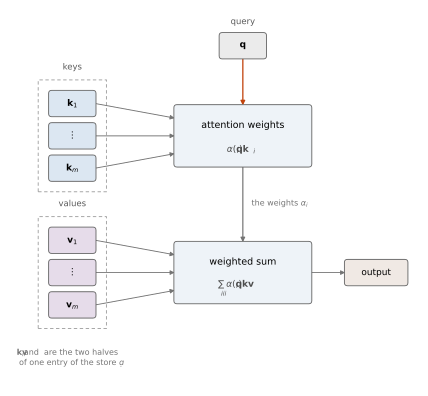

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import matplotlib.pyplot as plt

# palette shared with the rest of the course figures
KEY, VAL, OP, OUTC, DATA = '#dce7f2', '#e6dcea', '#eef3f8', '#f0e9e4', '0.92'
GREY, RED = '0.45', '#c1440e'

def soft_lookup_figure():
    """Attention in two stages.

    The keys meet the query to produce the weights; only then do the values
    enter.  Keeping those two stages apart is the whole point of the figure --
    computing the weights never looks at a value.
    """
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

    fig, ax = plt.subplots(figsize=(6.5, 5.3))
    bw, bh = 0.74, 0.40
    x_col, x_st, x_out = 0.0, 2.75, 4.90
    sw, sh = 2.20, 0.98

    rows_k = [1.12, 0.60, 0.08]
    rows_v = [-1.08, -1.60, -2.12]
    subs = ['1', None, 'm']
    y_w = sum(rows_k) / 3        # the weights stage, level with the keys
    y_s = sum(rows_v) / 3        # the sum stage, level with the values

    def box(xc, yc, text, fill, w=bw, h=bh, fs=9):
        ax.add_patch(FancyBboxPatch((xc - w / 2, yc - h / 2), w, h,
                                    boxstyle='round,pad=0.012,rounding_size=0.05',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=fill, zorder=3))
        ax.text(xc, yc, text, ha='center', va='center', fontsize=fs, zorder=4)

    def arrow(x0, y0, x1, y1, color=GREY, lw=0.9):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                     mutation_scale=9, linewidth=lw,
                                     color=color, shrinkA=0, shrinkB=0,
                                     zorder=1))

    def group(rows, letter, fill, label):
        lo, hi = min(rows) - bh / 2 - 0.18, max(rows) + bh / 2 + 0.18
        ax.add_patch(Rectangle((x_col - bw / 2 - 0.18, lo), bw + 0.36, hi - lo,
                               facecolor='none', edgecolor='0.6',
                               linewidth=0.85, linestyle=(0, (4, 3)), zorder=1))
        for y, s in zip(rows, subs):
            box(x_col, y, '$\\vdots$' if s is None
                else f'$\\mathbf{{{letter}}}_{s}$', fill)
        ax.text(x_col, hi + 0.14, label, ha='center', va='bottom',
                fontsize=8.5, color='0.35')
        return lo, hi

    group(rows_k, 'k', KEY, 'keys')
    group(rows_v, 'v', VAL, 'values')

    # stage 1: query meets keys, and nothing else
    box(x_st, y_w, '', OP, w=sw, h=sh)
    ax.text(x_st, y_w + 0.17, 'attention weights', ha='center', va='center',
            fontsize=9.5, zorder=4)
    ax.text(x_st, y_w - 0.22, '$\\alpha(\\mathbf{q}, \\mathbf{k}_i)$',
            ha='center', va='center', fontsize=9, color='0.3', zorder=4)

    # stage 2: the weights meet the values
    box(x_st, y_s, '', OP, w=sw, h=sh)
    ax.text(x_st, y_s + 0.17, 'weighted sum', ha='center', va='center',
            fontsize=9.5, zorder=4)
    ax.text(x_st, y_s - 0.24,
            '$\\sum_i \\alpha(\\mathbf{q},\\mathbf{k}_i)\\, \\mathbf{v}_i$',
            ha='center', va='center', fontsize=9, color='0.3', zorder=4)

    for y in rows_k:
        arrow(x_col + bw / 2, y, x_st - sw / 2, y_w + (y - y_w) * 0.55)
    for y in rows_v:
        arrow(x_col + bw / 2, y, x_st - sw / 2, y_s + (y - y_s) * 0.55)

    arrow(x_st, y_w - sh / 2, x_st, y_s + sh / 2, lw=1.2)
    ax.text(x_st + 0.14, (y_w + y_s) / 2, 'the weights $\\alpha_i$',
            ha='left', va='center', fontsize=8, color='0.45')

    # the query enters the first stage only
    y_q = y_w + 1.45
    box(x_st, y_q, '$\\mathbf{q}$', DATA)
    ax.text(x_st, y_q + bh / 2 + 0.12, 'query', ha='center', va='bottom',
            fontsize=8.5, color='0.35')
    arrow(x_st, y_q - bh / 2, x_st, y_w + sh / 2, color=RED, lw=1.3)

    box(x_out, y_s, 'output', OUTC, w=1.00)
    arrow(x_st + sw / 2, y_s, x_out - 0.50, y_s)

    ax.text(x_col, min(rows_v) - bh / 2 - 0.52,
            '$\\mathbf{k}_i$ and $\\mathbf{v}_i$ are the two halves\n'
            'of one entry of the store $\\mathcal{D}$',
            ha='center', va='top', fontsize=8, color='0.45', linespacing=1.4)

    ax.set_xlim(x_col - 1.05, x_out + 0.72)
    ax.set_ylim(min(rows_v) - 1.35, y_q + 0.62)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

soft_lookup_figure()

How should the weights be computed?  Two things are needed: a measure of how well each key matches the query, and a way to turn those measurements into weights that are nonnegative and sum to one.  For the second we already have the standard tool — the same one that turns class scores into probabilities in a classifier — so the whole question is what to measure.

## Computing the weights: the scaled dot product

The transformer measures the match between a query and a key with nearly the simplest choice available: the dot product $\mathbf{q}^\top \mathbf{k}$, which is large when the two point in similar directions.  (This requires queries and keys to have the same dimension $d$; exercise 1 lifts that restriction.)  One adjustment is needed.  Suppose the entries of $\mathbf{q}, \mathbf{k} \in \mathbb{R}^d$ are independent random variables with zero mean and unit variance — a reasonable picture of what activations look like early in training.  Then $\mathbf{q}^\top \mathbf{k}$ has mean zero but variance $d$: dot products grow in magnitude as $\sqrt{d}$ simply because more terms are being summed.  Dividing by $\sqrt{d}$ restores unit variance regardless of dimension.

Putting the two pieces together — scaled dot products to measure the match, softmax to normalize — gives the attention weights outright:

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}_i\!\left(\frac{\mathbf{q}^\top \mathbf{k}_i}{\sqrt{d}}\right) = \frac{\exp\!\big(\mathbf{q}^\top \mathbf{k}_i / \sqrt{d}\big)}{\sum_j \exp\!\big(\mathbf{q}^\top \mathbf{k}_j / \sqrt{d}\big)}.$$

This is **scaled dot product attention**, the attention operation of essentially every modern transformer (Vaswani et al., 2017, "Attention Is All You Need").  It also explains clue 2: the rows of the maps we plotted were softmax outputs, so of course they were nonnegative and summed to one.

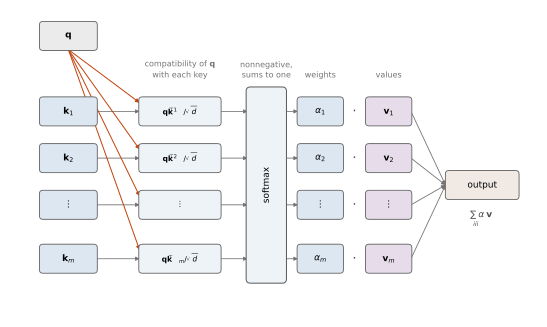

In [2]:
def attention_pipeline_figure():
    """The same lookup opened up: dot products, softmax, weighted sum."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

    from matplotlib.patches import Circle

    fig, ax = plt.subplots(figsize=(7.4, 4.35))
    bh = 0.38
    x_k, x_dot, x_sm, x_a, x_v, x_out = 0.0, 1.55, 2.75, 3.50, 4.45, 5.75
    rows = [1.00, 0.35, -0.30, -1.05]
    subs = ['1', '2', None, 'm']

    def box(xc, yc, text, fill, w=0.78, h=bh, fs=9):
        ax.add_patch(FancyBboxPatch((xc - w / 2, yc - h / 2), w, h,
                                    boxstyle='round,pad=0.012,rounding_size=0.05',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=fill, zorder=3))
        ax.text(xc, yc, text, ha='center', va='center', fontsize=fs, zorder=4)

    def arrow(x0, y0, x1, y1, color=GREY, lw=0.85):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                     mutation_scale=8, linewidth=lw,
                                     color=color, shrinkA=0, shrinkB=0,
                                     zorder=1))

    y_q = max(rows) + 1.05
    box(x_k, y_q, '$\\mathbf{q}$', DATA)

    for y, s in zip(rows, subs):
        dots = s is None
        box(x_k, y, '$\\vdots$' if dots else f'$\\mathbf{{k}}_{s}$', KEY)
        box(x_dot, y,
            '$\\vdots$' if dots else
            f'$\\mathbf{{q}}^\\top\\mathbf{{k}}_{s}/\\sqrt{{d}}$',
            OP, w=1.12, fs=7.5)
        arrow(x_k + 0.39, y, x_dot - 0.56, y)
        arrow(x_k, y_q - bh / 2, x_dot - 0.56, y + 0.12, color=RED, lw=1.0)

    # softmax acts on the whole column at once
    sw = 0.52
    sh = (max(rows) - min(rows)) + bh + 0.26
    ax.add_patch(FancyBboxPatch((x_sm - sw / 2, min(rows) - bh / 2 - 0.13), sw,
                                sh, boxstyle='round,pad=0.02,rounding_size=0.06',
                                linewidth=1.0, edgecolor='0.35', facecolor=OP,
                                zorder=2))
    ax.text(x_sm, (max(rows) + min(rows)) / 2, 'softmax', ha='center',
            va='center', fontsize=9, rotation=90, zorder=4)

    y_out = (max(rows) + min(rows)) / 2
    for y, s in zip(rows, subs):
        dots = s is None
        arrow(x_dot + 0.56, y, x_sm - sw / 2, y)
        arrow(x_sm + sw / 2, y, x_a - 0.31, y)
        box(x_a, y, '$\\vdots$' if dots else f'$\\alpha_{s}$', KEY, w=0.62)
        box(x_v, y, '$\\vdots$' if dots else f'$\\mathbf{{v}}_{s}$', VAL, w=0.62)
        # weight times value: the two boxes sit either side of the product dot
        ax.text((x_a + x_v) / 2, y, '·', ha='center', va='center',
                fontsize=13, color='0.3', zorder=4)
        arrow(x_v + 0.31, y, x_out - 0.51, y_out)

    box(x_out, y_out, 'output', OUTC, w=1.00)
    ax.text(x_out, y_out - bh / 2 - 0.14,
            '$\\sum_i \\alpha_i \\mathbf{v}_i$', ha='center', va='top',
            fontsize=9, color='0.3')

    top = max(rows) + bh / 2 + 0.26
    for x, note in ((x_dot, 'compatibility of $\\mathbf{q}$\nwith each key'),
                    (x_sm, 'nonnegative,\nsums to one'),
                    (x_a, 'weights'), (x_v, 'values')):
        ax.text(x, top, note, ha='center', va='bottom', fontsize=8,
                color='0.45', linespacing=1.4)

    ax.set_xlim(x_k - 0.85, x_out + 0.80)
    ax.set_ylim(min(rows) - 0.85, y_q + 0.40)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

attention_pipeline_figure()

Why does the variance matter enough to bother?  Because of what softmax does to large inputs.  Let's look at the two effects: first, that raw dot products really do grow as $\sqrt{d}$; then, what feeding large scores into softmax does to the weights.

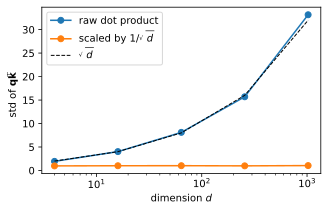

In [3]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import math

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt

torch.manual_seed(0)

dims = [4, 16, 64, 256, 1024]
stds_raw, stds_scaled = [], []
for d in dims:
    q = torch.randn(1000, d)
    k = torch.randn(1000, d)
    dots = (q * k).sum(dim=1)
    stds_raw.append(dots.std().item())
    stds_scaled.append((dots / math.sqrt(d)).std().item())

plt.figure(figsize=(5, 3))
plt.plot(dims, stds_raw, 'o-', label='raw dot product')
plt.plot(dims, stds_scaled, 'o-', label='scaled by $1/\\sqrt{d}$')
plt.plot(dims, np.sqrt(dims), 'k--', lw=1, label='$\\sqrt{d}$')
plt.xscale('log'); plt.xlabel('dimension $d$')
plt.ylabel('std of $\\mathbf{q}^\\top\\mathbf{k}$'); plt.legend();

Now the softmax side.  The cell below takes ten random scores, multiplies them by increasing factors — simulating what happens as $d$ grows without the $1/\sqrt{d}$ correction — and plots the resulting attention weights.

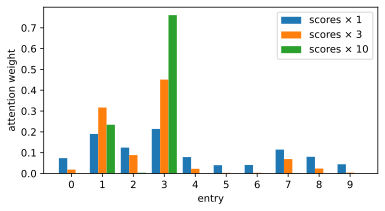

In [4]:
scores = torch.randn(10)
entries = np.arange(10)
scales = [1, 3, 10]
width = 0.27
plt.figure(figsize=(6, 3))
for k, scale in enumerate(scales):
    # bars, not a line: the ten entries are separate categories, not a
    # continuous signal, so there is nothing to interpolate between them
    plt.bar(entries + (k - 1) * width, F.softmax(scores * scale, dim=0),
            width=width, label=f'scores $\\times$ {scale}')
plt.xlabel('entry'); plt.ylabel('attention weight')
plt.xticks(entries); plt.legend();

As the scores grow, softmax saturates: nearly all the weight collapses onto the single largest score and the operation degenerates toward a hard, winner-take-all lookup.  In that regime the gradients with respect to the losing scores are nearly zero — softmax is flat there — so the model can barely learn to redistribute its attention.  The $1/\sqrt{d}$ factor keeps the scores in softmax's responsive range no matter how large we make the representation, which is exactly the kind of dimension-independence we required of initialization schemes for deep networks.

## From one query to a matrix of queries

In practice we never process one query at a time.  A sequence of $n$ positions issues $n$ queries at once — and this is where the parallelism we were promised comes from.  Stack the queries as rows of $\mathbf{Q} \in \mathbb{R}^{n \times d}$, the keys as rows of $\mathbf{K} \in \mathbb{R}^{m \times d}$, and the values as rows of $\mathbf{V} \in \mathbb{R}^{m \times v}$.  Then all $n \times m$ scores are computed by a single matrix product $\mathbf{Q}\mathbf{K}^\top$, and the entire attention operation is

$$\textrm{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \mathrm{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d}}\right)\mathbf{V} \;\in\; \mathbb{R}^{n \times v},$$

where the softmax is applied to each row of the score matrix separately.  Row $i$ of the output is exactly the single-query formula applied to query $\mathbf{q}_i$.  Note the shape of the computation: two large matrix multiplications and a row-wise softmax, no loops, no dependency between rows.  This is clue 1 resolved — all pairs of positions interact at once, in hardware-friendly form.

Let's implement it directly from the formula.  In PyTorch, `@` is matrix multiplication (`torch.matmul`), and `K.transpose(-2, -1)` swaps the last two axes to form $\mathbf{K}^\top$:

In [5]:
def attention(Q, K, V):
    """Scaled dot product attention.
    Q: (..., n, d), K: (..., m, d), V: (..., m, v).  The leading axes are
    optional batch dimensions (see below); the last two are the matrices.
    Returns (output, weights)."""
    d = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)   # (..., n, m)
    weights = F.softmax(scores, dim=-1)               # each row sums to 1
    return weights @ V, weights

n, m, d, v = 3, 10, 8, 5
Q, K, V = torch.randn(n, d), torch.randn(m, d), torch.randn(m, v)
output, weights = attention(Q, K, V)
print(output.shape, weights.shape)
print('row sums:', weights.sum(dim=1))

torch.Size([3, 5]) torch.Size([3, 10])
row sums: tensor([1.0000, 1.0000, 1.0000])


## One function, any batch shape

We wrote `attention` for a single sequence, yet the same code already handles a whole minibatch — and, in the next notebook, a minibatch of *attention heads* — with no changes at all.  The reason is `@` (`torch.matmul`): it treats the **last two axes** of each operand as the matrices to multiply and *broadcasts over every leading axis*.  Give it `Q, K, V` of shape `(batch, n, d)` and it solves one independent attention problem per batch element; give it `(batch, heads, n, d)` and it solves one per (sequence, head) pair.  `transpose(-2, -1)` likewise swaps the last two axes at any rank.

This is the current idiom.  Older code — including the d2l text this course grew from — reached for `torch.bmm`, which does the same thing but *only* for rank-3 tensors and so forces you to reshape multi-head tensors down to rank 3 and back.  `matmul` makes that bookkeeping unnecessary.  Watch the one function absorb a batch dimension:

In [6]:
# the very same attention(), now on a minibatch of b sequences
b = 4
Qb = torch.randn(b, n, d)
Kb = torch.randn(b, m, d)
Vb = torch.randn(b, m, v)
out_b, w_b = attention(Qb, Kb, Vb)
print('output:', out_b.shape, ' weights:', w_b.shape)  # one (n, m) per element

output: torch.Size([4, 3, 5])  weights: torch.Size([4, 3, 10])


## Checking our implementation against PyTorch's

This module's rule: every time we open a layer of the box, we verify that what we built is what was inside.  PyTorch exposes the exact operation we just wrote as `F.scaled_dot_product_attention` — it is the workhorse at the heart of `nn.TransformerEncoderLayer`, the black box we trained in notebook 1.  It accepts the same batched shapes, so we can check our version against it directly:

In [7]:
b, n, m, d, v = 4, 7, 10, 32, 32
Q = torch.randn(b, n, d)
K = torch.randn(b, m, d)
V = torch.randn(b, m, v)

ours, _ = attention(Q, K, V)
theirs = F.scaled_dot_product_attention(Q, K, V)
print('max difference:', (ours - theirs).abs().max().item())
assert torch.allclose(ours, theirs, atol=1e-5)
print('match!')

max difference: 3.5762786865234375e-07
match!


(The library version does not return the weights — production kernels avoid ever materializing the full $n \times m$ weight matrix in memory, which is one reason it is fast.  Our version returns them because we want to look at them.)

## Self-attention

So far, queries, keys, and values were three unrelated collections, as in a true dictionary lookup.  The transformer encoder uses attention in a particular configuration called **self-attention**: the queries, keys, and values are all derived from *the same sequence*.  In the simplest version, given input vectors $\mathbf{x}_1, \ldots, \mathbf{x}_n$ stacked into $\mathbf{X} \in \mathbb{R}^{n \times d}$, we set $\mathbf{Q} = \mathbf{K} = \mathbf{V} = \mathbf{X}$.  Each position asks, "which other positions look like me?" and gathers a weighted summary of them.  (In the full transformer, $\mathbf{Q}$, $\mathbf{K}$ and $\mathbf{V}$ are three different *learned linear transformations* of $\mathbf{X}$, so the model can decide what "looks like me" should mean — that refinement is the subject of the next notebook.)

To see the operation's character, here is a small synthetic example: eight input vectors forming two clusters plus one outlier, placed at *equal length* on a circle (the reason for equal length is discussed just below).  Since a position's query is its own vector, each position matches the keys of its cluster-mates:

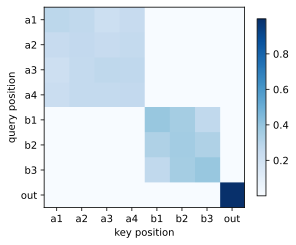

In [8]:
# eight points on a circle of radius R: same norm, differing only in
# direction (angle).  Grouping will therefore depend only on direction.
R = 3.0
def on_circle(degrees):
    a = torch.deg2rad(torch.tensor(degrees))
    return R * torch.stack([torch.cos(a), torch.sin(a)], dim=1)

X = on_circle([12, 20, 28, 24,      # cluster a
               150, 160, 170,       # cluster b
               -80])                # a lone outlier
labels = ['a1', 'a2', 'a3', 'a4', 'b1', 'b2', 'b3', 'out']

out, w = attention(X, X, X)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(w, cmap='Blues')
ax.set_xticks(range(8), labels)
ax.set_yticks(range(8), labels)
ax.set_xlabel('key position'); ax.set_ylabel('query position')
fig.colorbar(im, shrink=0.8);

The block structure is the point: positions in cluster *a* attend across cluster *a* fairly evenly, positions in *b* across *b*, while the outlier — having no near neighbors — falls back almost entirely on itself.  Attention groups positions by *content*.  In the sentiment model, this is how "not" can reach across the sentence for "bad": nothing in the mechanism refers to *where* a token is, only to *what* it is.

**Why equal-length vectors?**  The score $\mathbf{q}^\top\mathbf{k}$ grows with the *norm* of $\mathbf{k}$, not only with the alignment between $\mathbf{q}$ and $\mathbf{k}$.  So if some keys were longer than others, those keys would draw weight from *every* query regardless of direction, and the heatmap would show bright vertical stripes — columns that are dark top-to-bottom — overlaid on the block structure.  Those stripes are a real property of dot-product attention, but here they would only distract from the grouping we want to see, so we removed them by giving every vector the same length.  Real activations are *not* equal-length, and this same norm sensitivity is one reason transformers renormalize their activations at every layer (the layer normalization we add in notebook 5).  Exercise 3 asks you to reintroduce varying norms and watch the stripes appear.

That last observation is clue 3, and we can now state it precisely.  If we permute the rows of $\mathbf{X}$ (shuffle the word order), the score matrix's rows and columns permute accordingly, and the output is the same set of vectors, permuted the same way.  Formally, self-attention is **permutation-equivariant**: for any permutation matrix $\mathbf{P}$,

$$\textrm{Attention}(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{X}) = \mathbf{P}\,\textrm{Attention}(\mathbf{X}, \mathbf{X}, \mathbf{X}).$$

The word is worth pinning down, because a neighbouring one — *invariance* — is easy to confuse with it.  A function is permutation-**invariant** if permuting its input leaves the output unchanged, $f(\mathbf{P}\mathbf{X}) = f(\mathbf{X})$; it is permutation-**equivariant** if permuting the input permutes the output *the same way*, $f(\mathbf{P}\mathbf{X}) = \mathbf{P}\,f(\mathbf{X})$.  Self-attention is the equivariant kind: shuffle the tokens and the output vectors are not left unchanged, they are reshuffled to match.  (Each output vector's content is the same; only which slot it lands in moves.)  The operation treats its input as a *set* of vectors, not a sequence.  Let's verify numerically:

In [9]:
perm = torch.randperm(8)
out_then_perm = out[perm]
perm_then_out, _ = attention(X[perm], X[perm], X[perm])
print('max difference:', (out_then_perm - perm_then_out).abs().max().item())
assert torch.allclose(out_then_perm, perm_then_out, atol=1e-5)
print('self-attention is permutation-equivariant')

max difference: 7.152557373046875e-07
self-attention is permutation-equivariant


So the encoder as a whole — a stack of these layers — is equivariant too, since composing equivariant maps yields an equivariant map: permute the input words and every layer's outputs permute along.  The network's *prediction*, on the other hand, is permutation-**invariant**, and the reason is the readout.  After the equivariant stack we keep a single slot (our `<cls>` position; an average over positions would serve equally), and reading one fixed slot out of a reshuffled set returns the same vector whatever the order — a symmetric readout collapses the layers' equivariance into invariance of the output.  So: **the layers are equivariant, the network's output is invariant.**  That is the precise content of notebook 1's scrambling experiment, and it is why the model scores "this movie is not bad" and "this movie is bad, not..." identically.  The repair must happen at the input: position has to be written into the *content* of the vectors for attention to be able to use it.  That repair — the positional encoding — is built in the next notebook, alongside the other refinement we have flagged: the learned projections that produce queries, keys, and values in multiple parallel "heads".

## Summary

* Attention is a differentiable, soft dictionary lookup: a query is compared with all keys by scaled dot products, softmax turns the scores into nonnegative weights summing to one, and the output is the weight-averaged values.
* Scaling by $1/\sqrt{d}$ keeps the score variance independent of dimension; without it softmax saturates and gradients vanish.
* For $n$ queries and $m$ key–value pairs the whole operation is two matrix multiplications and a row-wise softmax — an all-pairs, fully parallel computation ($\mathcal{O}(nmd)$ work, and an $n \times m$ weight matrix: cost quadratic in sequence length when $m = n$).
* Our four-line implementation agrees with `F.scaled_dot_product_attention`, the kernel inside the black box of notebook 1.
* Self-attention is permutation-**equivariant** (permuting the input permutes the output identically); followed by a symmetric readout, the whole network's prediction is therefore permutation-**invariant** — it sees a set, not a sequence.  Order information must be injected separately.

## Exercises

1. Suppose queries have dimension $d_q$ and keys dimension $d_k \neq d_q$.  Modify dot product attention by inserting a matrix $\mathbf{M}$ so that the score becomes $\mathbf{q}^\top \mathbf{M} \mathbf{k}$.  What shape must $\mathbf{M}$ have?  What is the relationship to applying a linear projection to the queries first?
2. How do the computational cost and memory of `attention` scale with $n$, $m$, $d$, and $v$?  Which term dominates for long sequences?  Verify your answer by timing the function for a few sequence lengths.
3. **Make the stripes appear.**  Break the equal-length property: multiply each input vector by its own random factor, e.g. `Xn = X * (0.5 + torch.rand(8, 1))`, and re-plot `attention(Xn, Xn, Xn)`'s weights.  Identify the vertical stripes, find which key attracts the most weight, and compare its norm to the others.  Explain the pattern using the fact that $\mathbf{q}^\top\mathbf{k}$ scales with $\|\mathbf{k}\|$.
4. In the cluster example, replace softmax with weights proportional to the raw scores (normalized to sum to 1, allowing negatives).  What breaks, conceptually and numerically?
5. Multiply the scores by a "temperature" factor $\tau$ before the softmax ($\tau = 0.1, 1, 10$) and re-plot the cluster heatmap.  Connect what you see to the saturation experiment.